**BIDS Conversion for LOC EEG Experiment**

This notebook performs the conversion of raw BrainVision EEG data to the BIDS standard for a single participant. The workflow involves reading the raw data, applying a standard 10-20 montage to define sensor positions, mapping experimental annotations to event triggers, and writing the dataset to a BIDS-compliant directory structure.

The BIDS writer automatically creates the correct folder structure (e.g., sub-XX/eeg/), saves all EEG files (.vhdr, .vmrk, .eeg), generates event and channel metadata, CapTrak electrode and coordinate system files, and a sub-XX_scans.tsv file.

In [1]:
# Import libraries
import mne
import numpy as np
from pathlib import Path
from mne.channels import make_standard_montage
from mne_bids import BIDSPath, write_raw_bids

In [2]:
# Only change the participant ID to select which file you want to convert to BIDS format
sub_num = "14"

# Create file path to raw EEG data
data_path = Path(r"C:\Users\noahm\projects\loc_analysis\data\raw")
sub_dir = Path(f"s{sub_num}") / "eeg"
raw_fname = data_path / sub_dir / f"loc_s{sub_num}.vhdr"
print('Location of raw EEG files:', raw_fname)

Location of raw EEG files: C:\Users\noahm\projects\loc_analysis\data\raw\s14\eeg\loc_s14.vhdr


In [3]:
# Find and read the raw file
raw = mne.io.read_raw_brainvision(raw_fname)

# Print basic info - Does it match the online recording settings?
print(raw.info)

# Get indices of all channels
print("All channel names:")
print(raw.ch_names)

Extracting parameters from C:\Users\noahm\projects\loc_analysis\data\raw\s14\eeg\loc_s14.vhdr...
Setting channel info structure...
<Info | 7 non-empty values
 bads: []
 ch_names: Fp1, Fz, F3, F7, FT9, FC5, FC1, C3, T7, TP9, CP5, CP1, Pz, P3, ...
 chs: 63 EEG, 2 misc
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 280.0 Hz
 meas_date: 2026-01-28 15:37:37 UTC
 nchan: 65
 projs: []
 sfreq: 1000.0 Hz
>
All channel names:
['Fp1', 'Fz', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'TP9', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'TP10', 'CP6', 'CP2', 'Cz', 'C4', 'T8', 'FT10', 'FC6', 'FC2', 'F4', 'F8', 'Fp2', 'AF7', 'AF3', 'AFz', 'F1', 'F5', 'FT7', 'FC3', 'C1', 'C5', 'TP7', 'CP3', 'P1', 'P5', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'P6', 'P2', 'CPz', 'CP4', 'TP8', 'C6', 'C2', 'FC4', 'FT8', 'F6', 'AF8', 'AF4', 'F2', 'HEOG', 'VEOG']


C:\Users\noahm\AppData\Local\Temp\ipykernel_22036\627538605.py:2: RuntimeWarning: The unit for channel(s) HEOG, VEOG has changed from C to V.
  raw.set_channel_types({'HEOG': 'eog', 'VEOG': 'eog'})


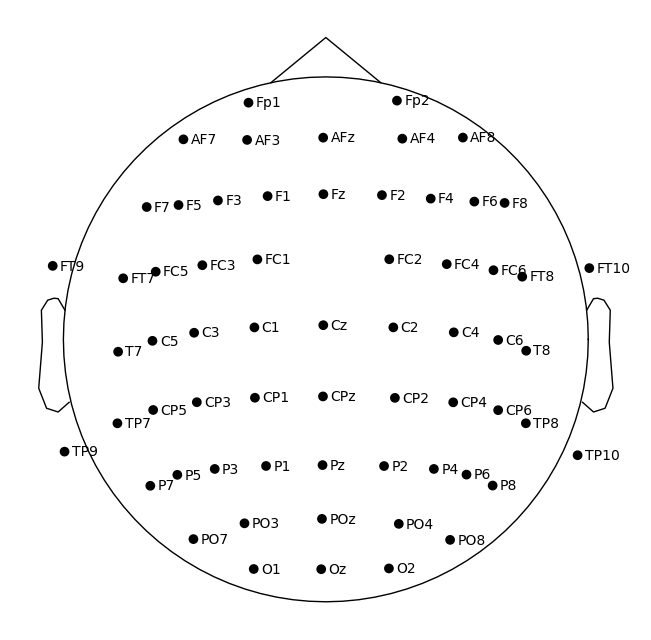

In [4]:
#Set channels types for the two EOG channels
raw.set_channel_types({'HEOG': 'eog', 'VEOG': 'eog'})

# Define the correct montage for the data available in MNE
montage = make_standard_montage("standard_1020")
raw.set_montage(montage, on_missing='warn') # set the montage to the data file

# 5. Verify montage set-up visually
raw.plot_sensors(show_names=True, sphere=(0.0, 0.02, 0.0, 0.09))

# Load available event keys and if you need to make new ones 
events, event_id = mne.events_from_annotations(raw, verbose=False) # Take the triggers


The trigger map was specified before implementing the experiment in PsychoPy and is used to recode the numerical trigger codes from the EEG recording back to meaningful event codes.

In [5]:
trigger_map = {
    # --- EXPERIMENT META ---
    'PLACEHOLDER': 99999,
    'psychopy_enc_starts': 1,

    # ----------------------------------
    # --- PHASE 0: PRACTICE (2-3) ---
    # ----------------------------------
    'prac_start': 2, #should appear once before practice trials, e.g., at "initialize" routine
    'prac_end': 3,   #should appear once after practice trials, e.g., at "practice end" routine. 

    # ----------------------------------
    # --- PHASE 1: ENCODING (100-199) loop ---
    # ----------------------------------
    'enc_start': 100, 

    'enc_fixation': 110, 
    'enc_cue': 101,
    'enc_act1': 102,
    'enc_act2': 103,
    'enc_act3': 104, 

    # Targets (The 2x2 Manipulation) in "target_trial" routine
    'tgt_sc_pc': 151,
    'tgt_sc_pi': 152,
    'tgt_si_pc': 153,
    'tgt_si_pi': 154,

    # Encoding Questions in "response" routine
    'enc_q_schema': 161, #Did the object reach the intended recipient?
    'enc_q_color': 162,  #Was the last panel colorized?

    # Encoding Responses (Left/Right)
    'enc_resp_left': 171,
    'enc_resp_right': 172,

    # Encoding phase ends
    'enc_end': 199,

    # ----------------------------------
    # --- PHASE 2: DISTRACTOR (50-51) ---
    # ----------------------------------
    'dist_start': 50,
    'dist_end': 51,

    # ----------------------------------
    # --- PHASE 3: RETRIEVAL (200+) ---
    # ----------------------------------
    'psychopy_ret_starts': 4,
    'ret_start': 200, 

    'ret_fixation': 210, 

    # A. Cue Display (Either 1 of 4 OLD conditions or 1 NEW condition)
    'ret_cue_old_sc_pc': 211,
    'ret_cue_old_sc_pi': 212,
    'ret_cue_old_si_pc': 213,
    'ret_cue_old_si_pi': 214,
    'ret_cue_new': 215,

    # B. Question 1: "Seen before?" (Either 1 of 4 OLD conditions or 1 NEW condition) during "cue_recog" routine
    'ret_q1_old_sc_pc': 221,
    'ret_q1_old_sc_pi': 222,
    'ret_q1_old_si_pc': 223,
    'ret_q1_old_si_pi': 224,
    'ret_q1_new': 225,

    'ret_q1_resp_left': 228,  
    'ret_q1_resp_right': 229, 

    # C. Question 2: "Unexpected?" (Either 1 of 4 OLD conditions or 1 NEW condition) during "ending_recall" routine
    'ret_q2_old_sc_pc': 231,
    'ret_q2_old_sc_pi': 232,
    'ret_q2_old_si_pc': 233,
    'ret_q2_old_si_pi': 234,
    'ret_q2_new': 235,

    'ret_q2_resp_left': 238,  
    'ret_q2_resp_right': 239, 

    # D. Target Selection (4 Choices) (Either 1 of 4 OLD conditions or 1 NEW condition) during "target_trial" routine
    'ret_q3_old_sc_pc': 241,
    'ret_q3_old_sc_pi': 242,
    'ret_q3_old_si_pc': 243,
    'ret_q3_old_si_pi': 244,
    'ret_q3_new': 245,

    'ret_q3_resp_1': 251,
    'ret_q3_resp_2': 252,
    'ret_q3_resp_3': 253,
    'ret_q3_resp_4': 254,

    'ret_end': 209
}

Now, the dataset can be converted into BIDS format. After this code has ran, navigate the newly created directory to ensure that all files were created as expected.

In [6]:
# Remove annotations so I can fill the event_id-s with descriptions
raw.set_annotations(None)

# Set a new root path for the bidsyfied files
new_path = Path(r"C:\Users\noahm\projects\loc_analysis\data\derivatives")
bids_root = Path(new_path)

# Datatype might also be inferred automatically, but it's safer to specify it
bids_path = BIDSPath(
    subject=sub_num,
    datatype="eeg", 
    task="loc",
    root=bids_root
)

# Add extensions to the path
bids_path.update(suffix="eeg", extension=".vhdr")

# Power line frequency missing in raw.info
raw.info["line_freq"] = 50  # required by BIDS. 50Hz in Spain

# Create bids structure for the participant
write_raw_bids(
    raw,
    bids_path=bids_path,
    events=events,
    event_id=trigger_map,
    overwrite=True,
    verbose=True,
)

# After running this notebook, the EEG data for the participant should be in their respective data/derivates/ folder.

Extracting parameters from C:\Users\noahm\projects\loc_analysis\data\raw\s14\eeg\loc_s14.vhdr...
Setting channel info structure...
Writing 'C:\Users\noahm\projects\loc_analysis\data\derivatives\participants.tsv'...
Writing 'C:\Users\noahm\projects\loc_analysis\data\derivatives\participants.json'...
Writing 'C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-14\eeg\sub-14_space-CapTrak_electrodes.tsv'...
Writing 'C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-14\eeg\sub-14_space-CapTrak_coordsystem.json'...
Used Annotations descriptions: [np.str_('dist_end'), np.str_('dist_start'), np.str_('enc_act1'), np.str_('enc_act2'), np.str_('enc_act3'), np.str_('enc_cue'), np.str_('enc_end'), np.str_('enc_fixation'), np.str_('enc_q_color'), np.str_('enc_q_schema'), np.str_('enc_resp_left'), np.str_('enc_resp_right'), np.str_('enc_start'), np.str_('prac_end'), np.str_('prac_start'), np.str_('psychopy_enc_starts'), np.str_('psychopy_ret_starts'), np.str_('ret_cue_new'), np.str_('r

BIDSPath(
root: C:/Users/noahm/projects/loc_analysis/data/derivatives
datatype: eeg
basename: sub-14_task-loc_eeg.vhdr)